# 2 - E-commerce Analytics Dashboard - Data Visualization

<img src='https://www.the-future-of-commerce.com/wp-content/uploads/2020/01/what-is-e-commerce-SOCIAL.jpg'>

Bu çalışmada e-ticaret verileri üzerinden sipariş, gelir, ülke ve ürün bazlı performansı görselleştirerek analiz edeceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Temel istatistik ve ilişki analizi
6. KPI analizi
7. Ürün bazlı görselleştirme
8. Ülke bazlı görselleştirme
9. Zaman bazlı görselleştirme
10. Sonuç


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


## 1. Veriyi Yükleme

In [2]:
# Bu bölümde zip dosyasını Google Drive içinden açıp çalışma alanına çıkaracağım.

In [3]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/E-Commerce Data.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]


Mounted at /content/drive


['.config', 'drive', 'data.csv', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [4]:
# Bu bölümde csv dosyasını okuyup veri setinin genel yapısını inceleyeceğim.

In [5]:
df = pd.read_csv('/content/data.csv', encoding='latin1')
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.shape


(541909, 8)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


## 3. Veri Temizleme

In [9]:
# Bu bölümde eksik müşteri bilgilerini ve negatif miktarları temizleyerek analiz için daha uygun bir veri seti oluşturacağım.

In [10]:
df = df.dropna(subset=['CustomerID', 'Description'])
df = df[df['Quantity'] > 0]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 4. Feature Engineering

In [11]:
# Bu bölümde tarih dönüşümü, toplam gelir ve zaman alanları gibi analizde kullanacağım yeni sütunları oluşturacağım.

In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month_name()
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December


## 5. Temel İstatistik ve İlişki Analizi

In [13]:
# Bu bölümde describe, korelasyon ve temel grafiklerle veri setindeki ilişkileri inceleyeceğim.

In [14]:
df[['Quantity', 'UnitPrice', 'Revenue']].describe()


,Quantity,UnitPrice,Revenue
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,22.394749
std,180.420210,22.096788,309.055588
min,1.000000,0.000000,0.000000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [15]:
corr_df = df[['Quantity', 'UnitPrice', 'Revenue']].corr(numeric_only=True)
corr_df


,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.004561,0.908812
UnitPrice,-0.004561,1.000000,0.081646
Revenue,0.908812,0.081646,1.000000


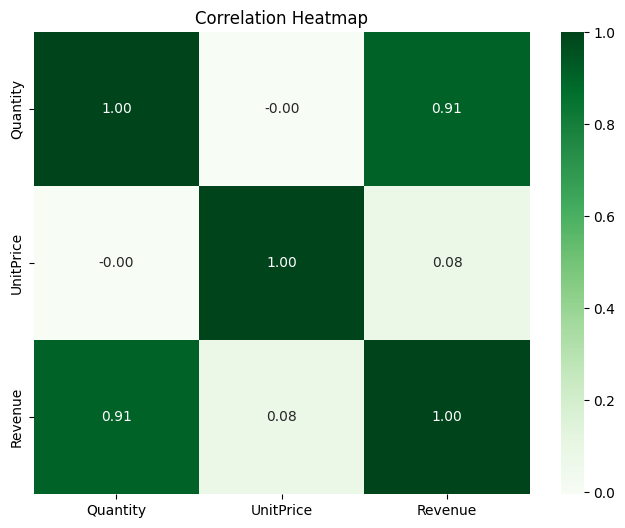

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap='Greens', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


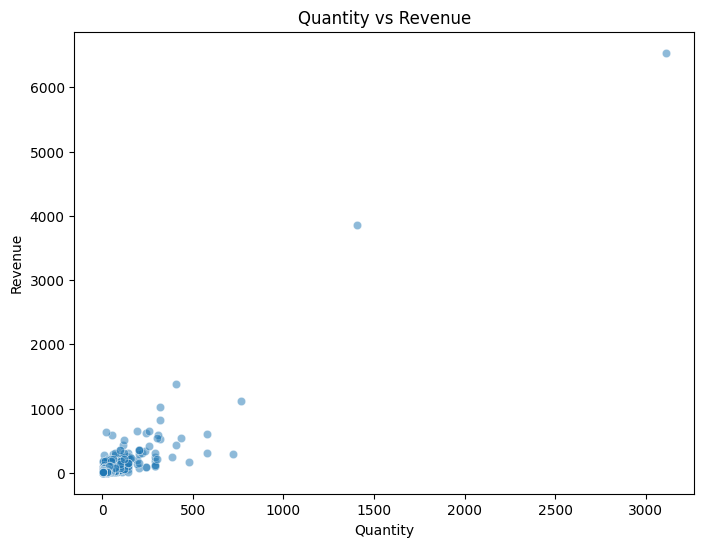

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df.sample(min(5000, len(df))), x='Quantity', y='Revenue', alpha=0.5)
plt.title('Quantity vs Revenue')
plt.show()


## 6. KPI Analizi

In [18]:
# Bu bölümde toplam gelir, toplam sipariş ve toplam müşteri sayısı gibi temel KPI değerlerini inceleyeceğim.

In [19]:
total_revenue = df['Revenue'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()

print('Total Revenue:', round(total_revenue, 2))
print('Total Orders:', total_orders)
print('Total Customers:', total_customers)


Total Revenue: 8911407.9
Total Orders: 18536
Total Customers: 4339


## 7. Ürün Bazlı Görselleştirme

In [20]:
# Bu bölümde en çok gelir getiren ürünleri ve ürün bazlı performansı görselleştireceğim.

In [21]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(top_products, x='Revenue', y='Description', orientation='h', title='Top 10 Products by Revenue')
fig.show()


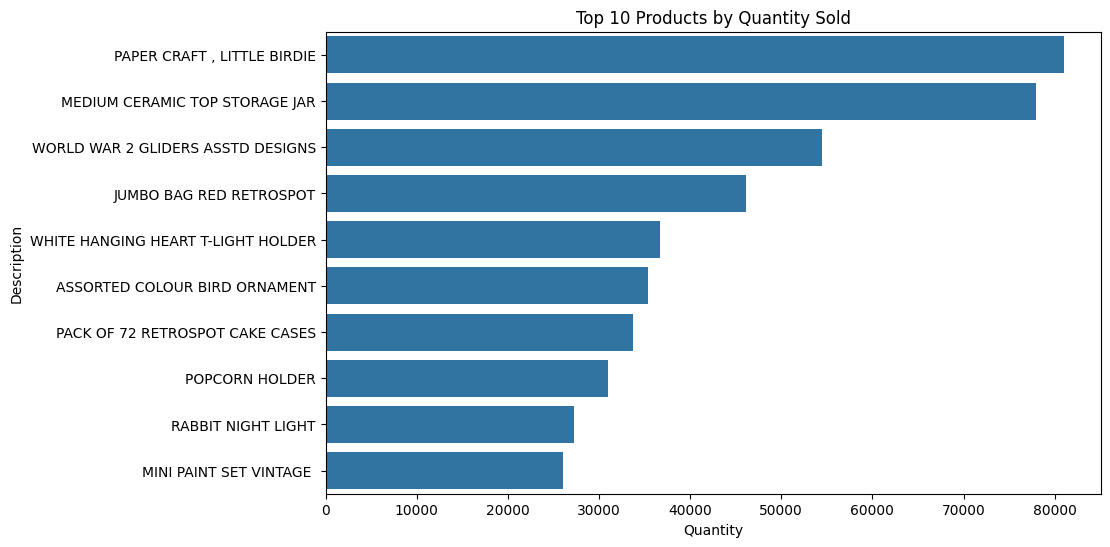

In [22]:
top_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=top_quantity, x='Quantity', y='Description')
plt.title('Top 10 Products by Quantity Sold')
plt.show()


## 8. Ülke Bazlı Görselleştirme

In [23]:
# Bu bölümde ülkelere göre gelir ve sipariş dağılımını inceleyeceğim.

In [24]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(country_revenue, x='Country', y='Revenue', title='Top 10 Countries by Revenue')
fig.show()


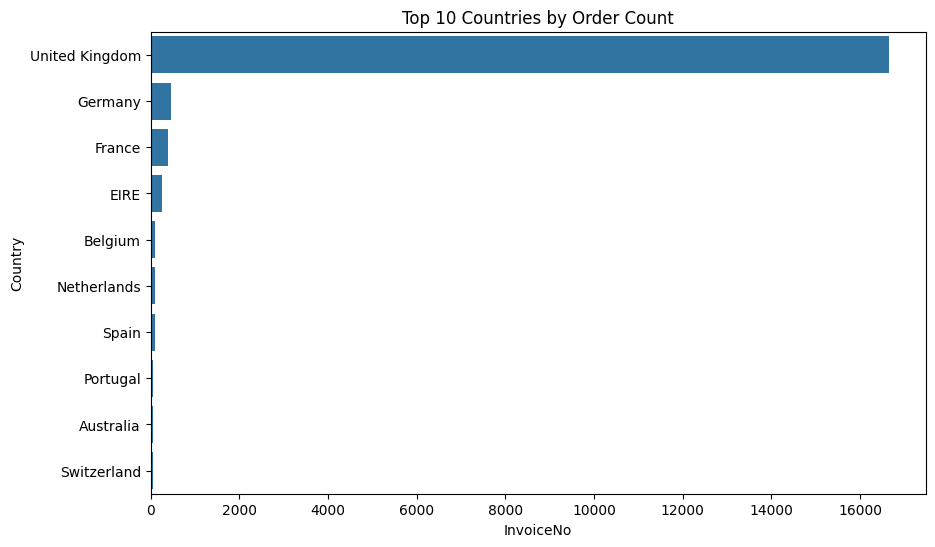

In [25]:
country_orders = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=country_orders, x='InvoiceNo', y='Country')
plt.title('Top 10 Countries by Order Count')
plt.show()


## 9. Zaman Bazlı Görselleştirme

In [26]:
# Bu bölümde aylara göre gelir değişimini görselleştirerek satış trendini inceleyeceğim.

In [27]:
monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_revenue['Month'] = pd.Categorical(monthly_revenue['Month'], categories=month_order, ordered=True)
monthly_revenue = monthly_revenue.sort_values('Month')

fig = px.line(monthly_revenue, x='Month', y='Revenue', markers=True, title='Monthly Revenue Trend')
fig.show()


## 10. Sonuç

Bu projede e-ticaret verileri görselleştirme odaklı olarak analiz edildi. Elde edilen grafikler ve dashboard çıktıları ile ürün, ülke ve zaman bazında gelir performansı anlaşılır şekilde ortaya kondu.